In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from graph_analysis import read_pajek
import os
from networkx.drawing.layout import (
    spring_layout, circular_layout, random_layout, shell_layout,
    spiral_layout, spectral_layout, kamada_kawai_layout
)

import igraph as ig
import leidenalg

In [2]:
def get_layout(G, layout_name):
    if layout_name == 'spring':
        return nx.spring_layout(G, k=1, iterations=50)
    elif layout_name == 'circular':
        return nx.circular_layout(G)
    elif layout_name == 'random':
        return nx.random_layout(G)
    elif layout_name == 'shell':
        return nx.shell_layout(G)
    elif layout_name == 'spiral':
        return nx.spiral_layout(G)
    elif layout_name == 'spectral':
        return nx.spectral_layout(G)
    elif layout_name == 'kamada_kawai':
        return nx.kamada_kawai_layout(G)
    elif layout_name == 'forceatlas2_layout':
        return nx.forceatlas2_layout(G)
    elif layout_name == 'arf_layout':
        return nx.arf_layout(G)
    elif layout_name == 'bipartite_layout':
        return nx.bipartite_layout(G, nodes=G.nodes())
    elif layout_name == 'planar_layout':
        return nx.planar_layout(G)
    elif layout_name == 'multipartite_layout':
        return nx.multipartite_layout(G, subset_key='bipartite')
    elif layout_name == 'bfs_layout':
        return nx.bfs_layout(G, source=0)
    elif layout_name == 'rescale_layout':
        return nx.rescale_layout(G, scale=1.0)
    elif layout_name == 'fruchterman_reingold_layout':
        return nx.fruchterman_reingold_layout(G)
    
    else:
        return nx.spring_layout(G)

def visualize_network(
    G,
    title,
    output_path,
    layout_name='spring',
    node_size=100,
    edge_gray='gray',
    alpha=0.6,
    figsize=(15, 15),
    resolution=1.0, # resolution parameter for Leiden algorithm
    plot_communities=False # Changed from visualize_separate_communities
):
    try:
        # --- Community Detection and Color Mapping (Moved Up) ---
        nodes = list(G.nodes())
        idx_map = {n: i for i, n in enumerate(nodes)}
        edges_idx = [(idx_map[u], idx_map[v]) for u, v in G.edges()]

        if not isinstance(G, nx.Graph):
            print("Warning: G is not a NetworkX graph. Conversion to igraph might be problematic.")
            # Potentially handle this case more robustly if G can be other types
            pass

        ig_g = ig.Graph(n=len(nodes), edges=edges_idx, directed=G.is_directed())
        ig_g.vs['name'] = nodes
        
        weights_on_edges = False
        # Check for weights more carefully
        if G.number_of_edges() > 0:
            # Get data of the first edge to check for 'weight' attribute
            # This assumes if one edge has 'weight', all intended for weighting do.
            # A more robust check might iterate or ensure all edges have it.
            u, v, first_edge_data = next(iter(G.edges(data=True)))
            if 'weight' in first_edge_data:
                try:
                    weights = [data.get('weight', 1.0) for _, _, data in G.edges(data=True)]
                    if weights: # Ensure weights list is not empty and all are numbers
                         # Filter out None or non-numeric weights if necessary, or ensure they are all valid
                        valid_weights = [w for w in weights if isinstance(w, (int, float))]
                        if len(valid_weights) == G.number_of_edges():
                            ig_g.es['weight'] = valid_weights
                            weights_on_edges = True
                        else:
                            print("Warning: Some edges have missing or non-numeric weights. Proceeding without weights for Leiden.")
                except Exception as e:
                    print(f"Error processing edge weights: {e}. Proceeding without weights for Leiden.")


        partition_type = leidenalg.RBConfigurationVertexPartition
        
        if weights_on_edges:
            partition = leidenalg.find_partition(
                ig_g,
                partition_type,
                resolution_parameter=resolution,
                weights='weight' 
            )
        else:
            partition = leidenalg.find_partition(
                ig_g,
                partition_type,
                resolution_parameter=resolution
            )
            
        membership = partition.membership
        comm_dict = {}
        for idx, comm_id_val in enumerate(membership): # Renamed comm_id to comm_id_val to avoid conflict
            comm_dict.setdefault(comm_id_val, []).append(idx)
        num_comms = len(comm_dict)

        color_map = {}
        if num_comms > 0:
            cmap = plt.cm.get_cmap('Set3', num_comms)
            color_map = {
                nodes[idx]: cmap(comm_id_val % cmap.N) 
                for comm_id_val, idxs in comm_dict.items()
                for idx in idxs
            }
        # --- End of Moved Up Section ---

        if plot_communities:
            if num_comms == 0:
                print(f"No communities found for {title} to plot separately.")
                return # Exit if no communities to plot

            for comm_id, node_indices_in_comm in comm_dict.items():
                community_node_objects = [nodes[i] for i in node_indices_in_comm]
                subgraph = G.subgraph(community_node_objects)

                if subgraph.number_of_nodes() == 0:
                    continue

                plt.figure(figsize=figsize) 
                
                try:
                    pos_sub = get_layout(subgraph, layout_name)
                except Exception as layout_exc:
                    print(f"Could not compute layout {layout_name} for community {comm_id}. Using spring_layout. Error: {layout_exc}")
                    pos_sub = nx.spring_layout(subgraph) # Fallback layout

                subgraph_node_colors = [color_map.get(n, 'grey') for n in subgraph.nodes()]

                nx.draw_networkx_nodes(subgraph, pos_sub, node_size=node_size,
                                       node_color=subgraph_node_colors, alpha=alpha)
                subgraph_edge_colors = [color_map.get(u, edge_gray) for u,v in subgraph.edges()]
                nx.draw_networkx_edges(subgraph, pos_sub, edge_color=subgraph_edge_colors, alpha=alpha/2, arrows=subgraph.is_directed())
                
                sub_all_labels = nx.get_node_attributes(subgraph, 'label') or {n: str(n) for n in subgraph.nodes()}
                
                # Get top 50 nodes by degree in the subgraph
                potential_top30_sub_nodes = [node for node, degree in sorted(subgraph.degree, key=lambda x: x[1], reverse=True)[:30]]
                
                # Filter these nodes to include only those for which a position was computed by the layout
                drawable_nodes_for_labels = [node for node in potential_top30_sub_nodes if node in pos_sub]
                
                labels_sub = {n: sub_all_labels.get(n, str(n)) for n in drawable_nodes_for_labels}
                
                if labels_sub: # Only attempt to draw labels if there are any valid ones
                    nx.draw_networkx_labels(subgraph, pos_sub, labels_sub, font_size=8)
                
                plt.title(f'{title} - Community {comm_id} - {layout_name.capitalize()}')
        else: # Plot the full graph
            plt.figure(figsize=figsize)
            if num_comms == 0:
                print(f"No communities found for {title}. Drawing graph without community coloring.")
                pos = get_layout(G, layout_name)
                # Draw basic graph if no communities
                all_labels_full = nx.get_node_attributes(G, 'label') or {n: str(n) for n in G.nodes()}
                pr_full = nx.pagerank(G)
                top50_full = sorted(pr_full, key=pr_full.get, reverse=True)[:30]
                labels_full = {n: all_labels_full.get(n, str(n)) for n in top50_full}

                pr_values = list(pr_full.values())
                min_size, max_size = 20, 800  # adjust to your liking

                def scale_size(pr):
                    if len(pr_values) == 0 or max(pr_values) == min(pr_values):
                        return node_size  # fallback to default size if PR is degenerate
                    return min_size + (max_size - min_size) * ((pr - min(pr_values)) / (max(pr_values) - min(pr_values)))

                node_sizes = [scale_size(pr_full.get(n, 0)) for n in G.nodes()]

                nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=alpha, node_color='lightgrey')
                nx.draw_networkx_edges(G, pos, alpha=alpha/2, arrows=G.is_directed(), edge_color=edge_gray)
                nx.draw_networkx_labels(G, pos, labels_full, font_size=8)
                plt.title(f'{title} – {layout_name.capitalize()} (No communities)')
            else:
                node_colors = [color_map.get(n, 'grey') for n in G.nodes()]
                edge_colors = [color_map.get(u, edge_gray) for u, v in G.edges()]

                pos = get_layout(G, layout_name)
                nx.draw_networkx_nodes(G, pos, node_size=node_size,
                                       node_color=node_colors, alpha=alpha)
                nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                                       alpha=alpha/2, arrows=G.is_directed())
                
                pr = nx.pagerank(G)
                top50 = sorted(pr, key=pr.get, reverse=True)[:30]
                all_labels = nx.get_node_attributes(G, 'label') or {n: str(n) for n in G.nodes()}
                labels = {n: all_labels.get(n, str(n)) for n in top50}
                nx.draw_networkx_labels(G, pos, labels, font_size=8)
                
                plt.title(f'{title} – {layout_name.capitalize()} ({num_comms} communities)')
            
            plt.axis('off')
            dirpath = os.path.dirname(output_path)
            if dirpath and not os.path.exists(dirpath):
                os.makedirs(dirpath, exist_ok=True)
            
            main_save_path = f"{os.path.splitext(output_path)[0]}_{layout_name}.png"
            plt.savefig(main_save_path, dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()
            print(f"Created main network visualization with {layout_name} layout: {main_save_path}")

    except Exception as e:
        print(f"Error in visualize_network for {title} with {layout_name} layout: {e}")
        import traceback
        traceback.print_exc()

# TDF_time_diff.net

In [ ]:
# Load time_diff network
G_time_diff, names = read_pajek("TDF_time_diff", "../output_graphs")
print(f"Successfully loaded network with {G_time_diff.number_of_nodes()} nodes and {G_time_diff.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='kamada_kawai',
    resolution=1
)


KeyboardInterrupt: 

C:\Users\tgrum\AppData\Local\Temp\ipykernel_11720\1005364289.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


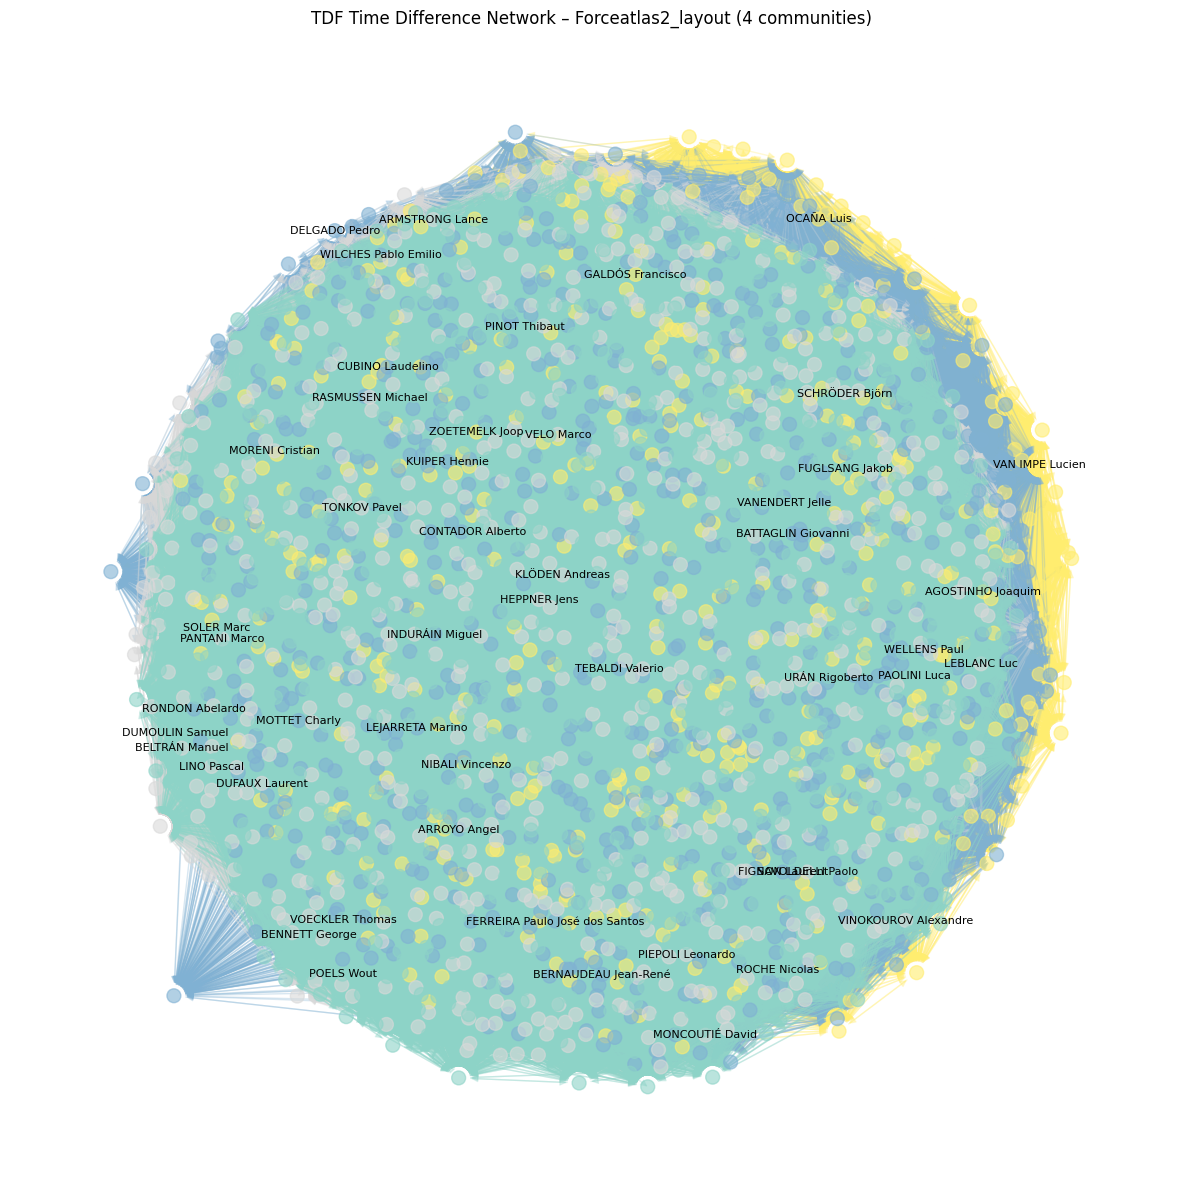

Created network visualization with forceatlas2_layout layout: tdf_time_diff_forceatlas2_layout.png


In [ ]:
# sprobaj se forceatlas2_layout, dodaj ga v visualize_network funkcijo in pozeni tole:
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='forceatlas2_layout',
    resolution=1
)

C:\Users\tgrum\AppData\Local\Temp\ipykernel_11720\2505212964.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


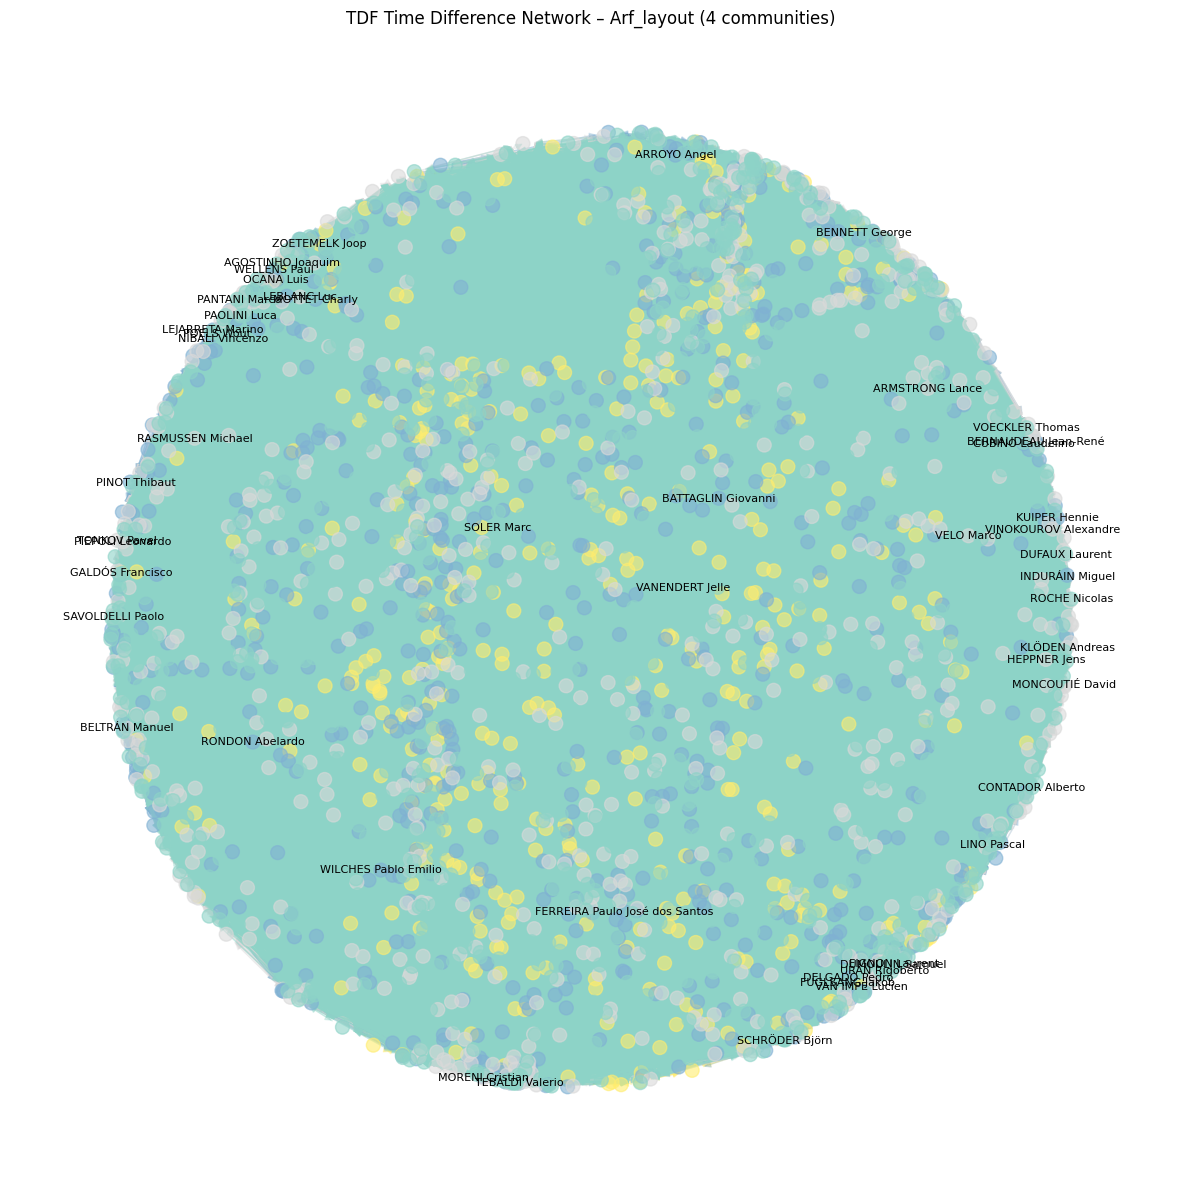

Created network visualization with arf_layout layout: tdf_time_diff_arf_layout.png


In [ ]:
# sprobaj se forceatlas2_layout, dodaj ga v visualize_network funkcijo in pozeni tole:
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='arf_layout',
    resolution=1
)

C:\Users\tgrum\AppData\Local\Temp\ipykernel_11720\4070147902.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


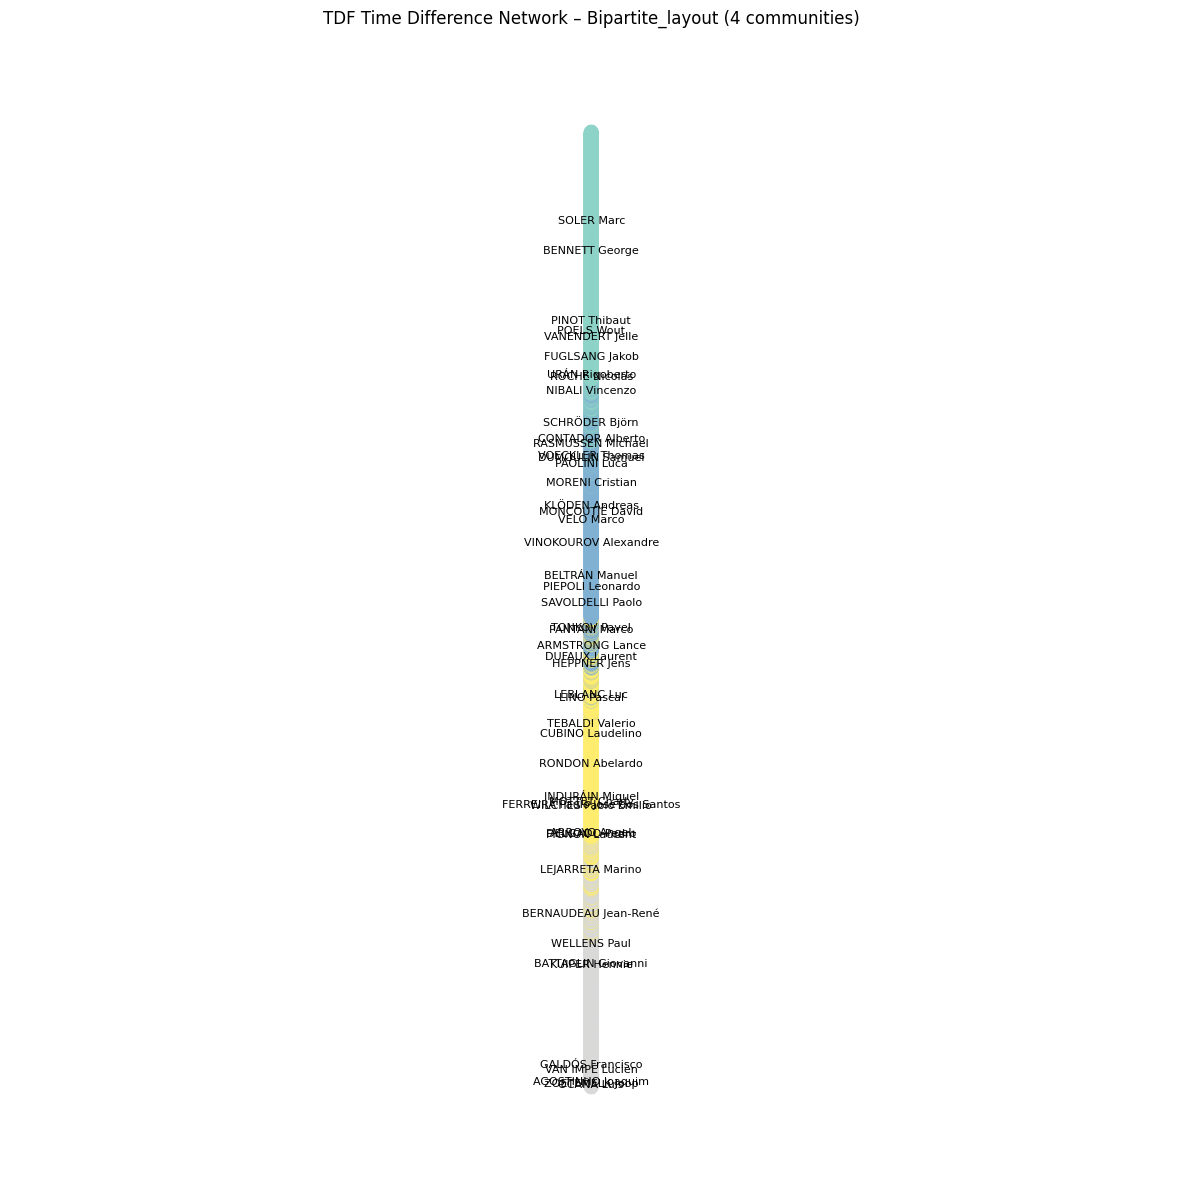

Created network visualization with bipartite_layout layout: tdf_time_diff_bipartite_layout.png
Error creating planar_layout layout visualization for TDF Time Difference Network: G is not planar.
Error creating multipartite_layout layout visualization for TDF Time Difference Network: all nodes need a subset_key attribute: bipartite
Error creating bfs_layout layout visualization for TDF Time Difference Network: bfs_layout() got an unexpected keyword argument 'source'
Error creating rescale_layout layout visualization for TDF Time Difference Network: 'DiGraph' object has no attribute 'mean'


<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

In [ ]:
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='bipartite_layout',
    resolution=1
)
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='planar_layout',
    resolution=1
)
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='multipartite_layout',
    resolution=1
)
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='bfs_layout',
    resolution=1
)
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='rescale_layout',
    resolution=1
)


In [ ]:
G_time_diff, names = read_pajek("TDF_time_diff", "./output_graphs")

visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='fruchterman_reingold_layout',
    resolution=1,
    plot_communities=False
)

C:\Users\Martin\AppData\Local\Temp\ipykernel_21612\2623264347.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


C:\Users\tgrum\AppData\Local\Temp\ipykernel_17388\1920711012.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


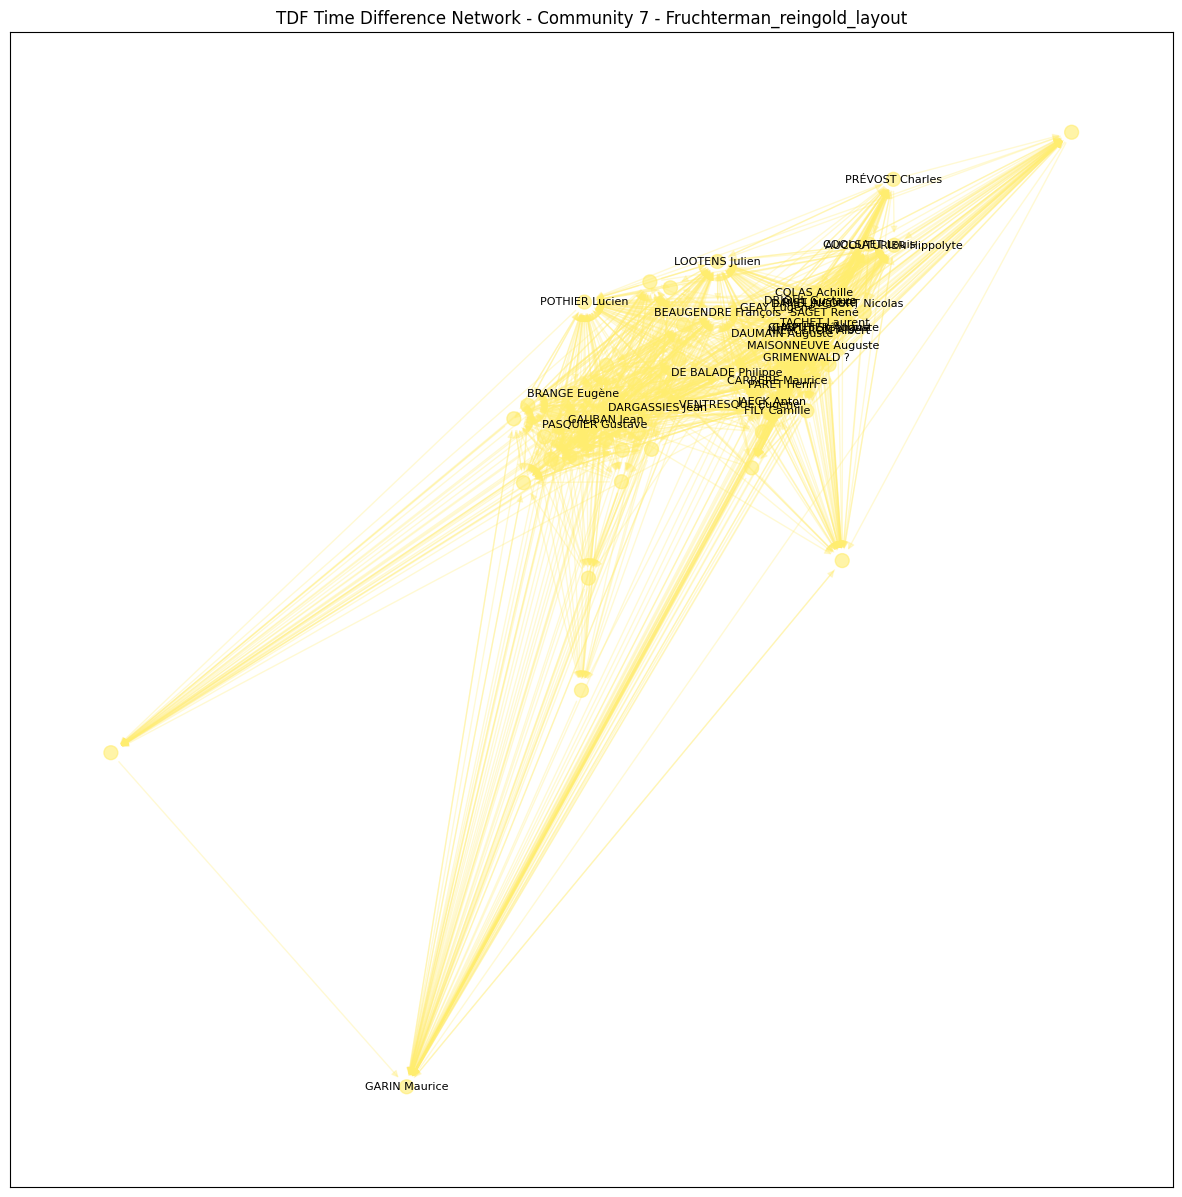

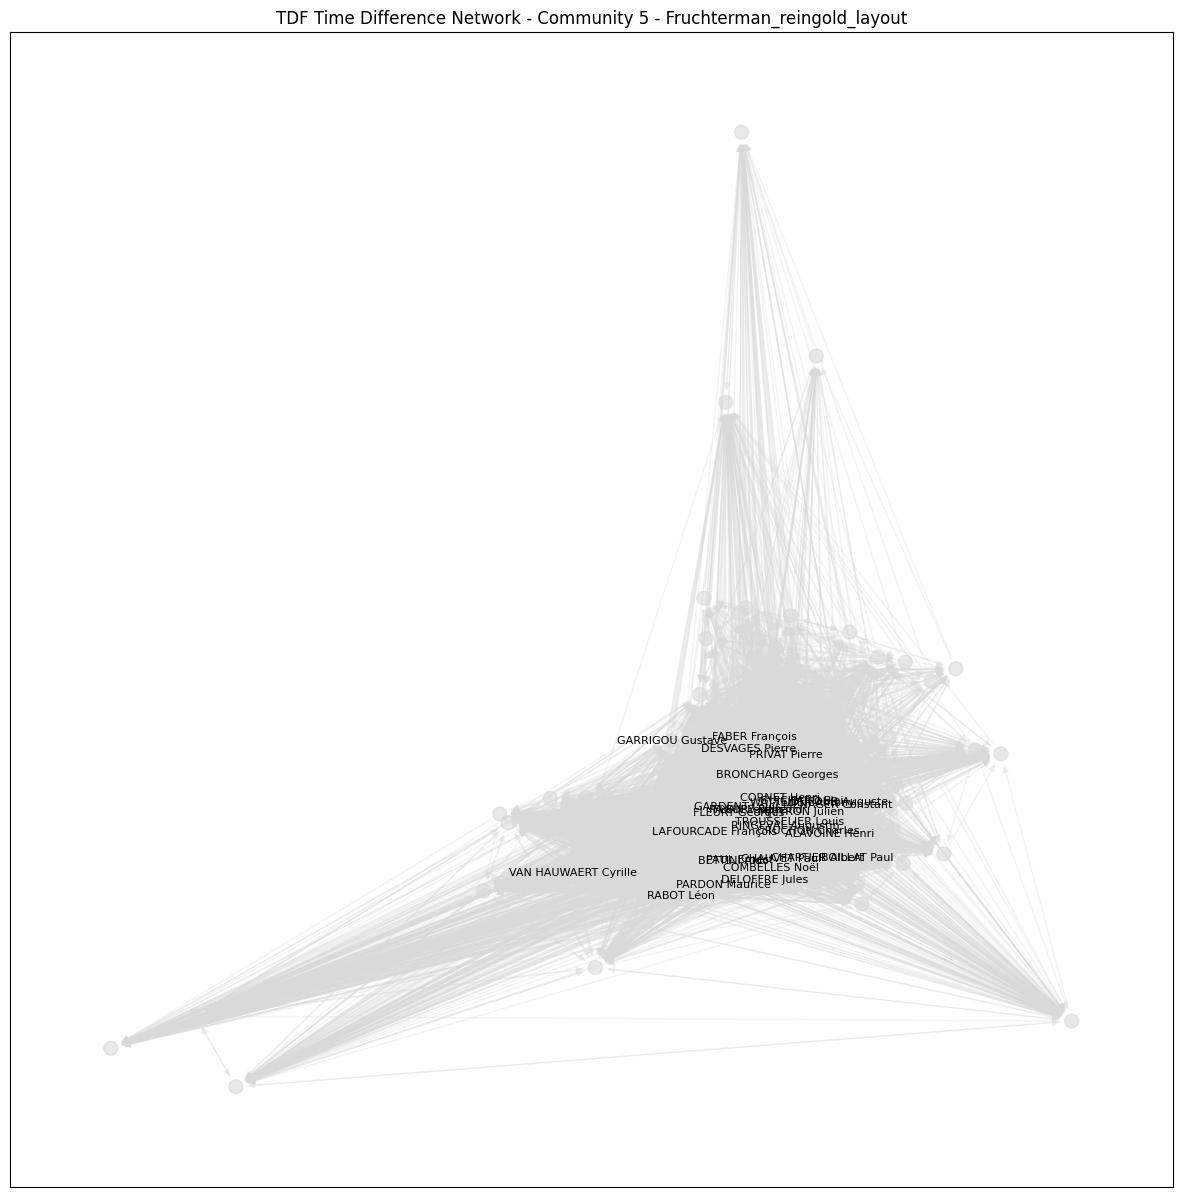

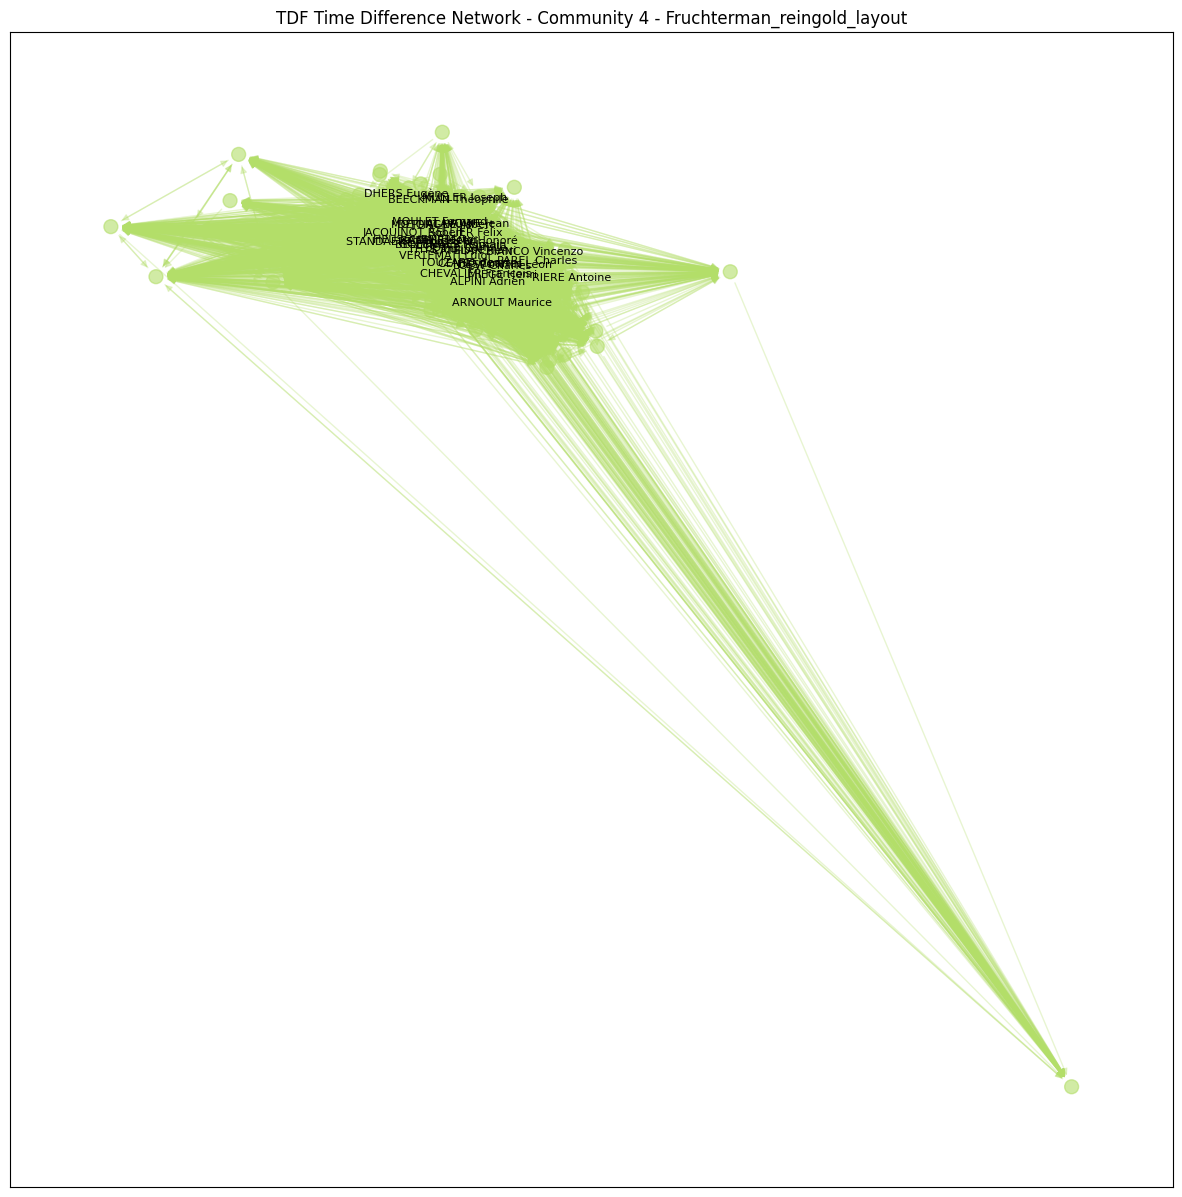

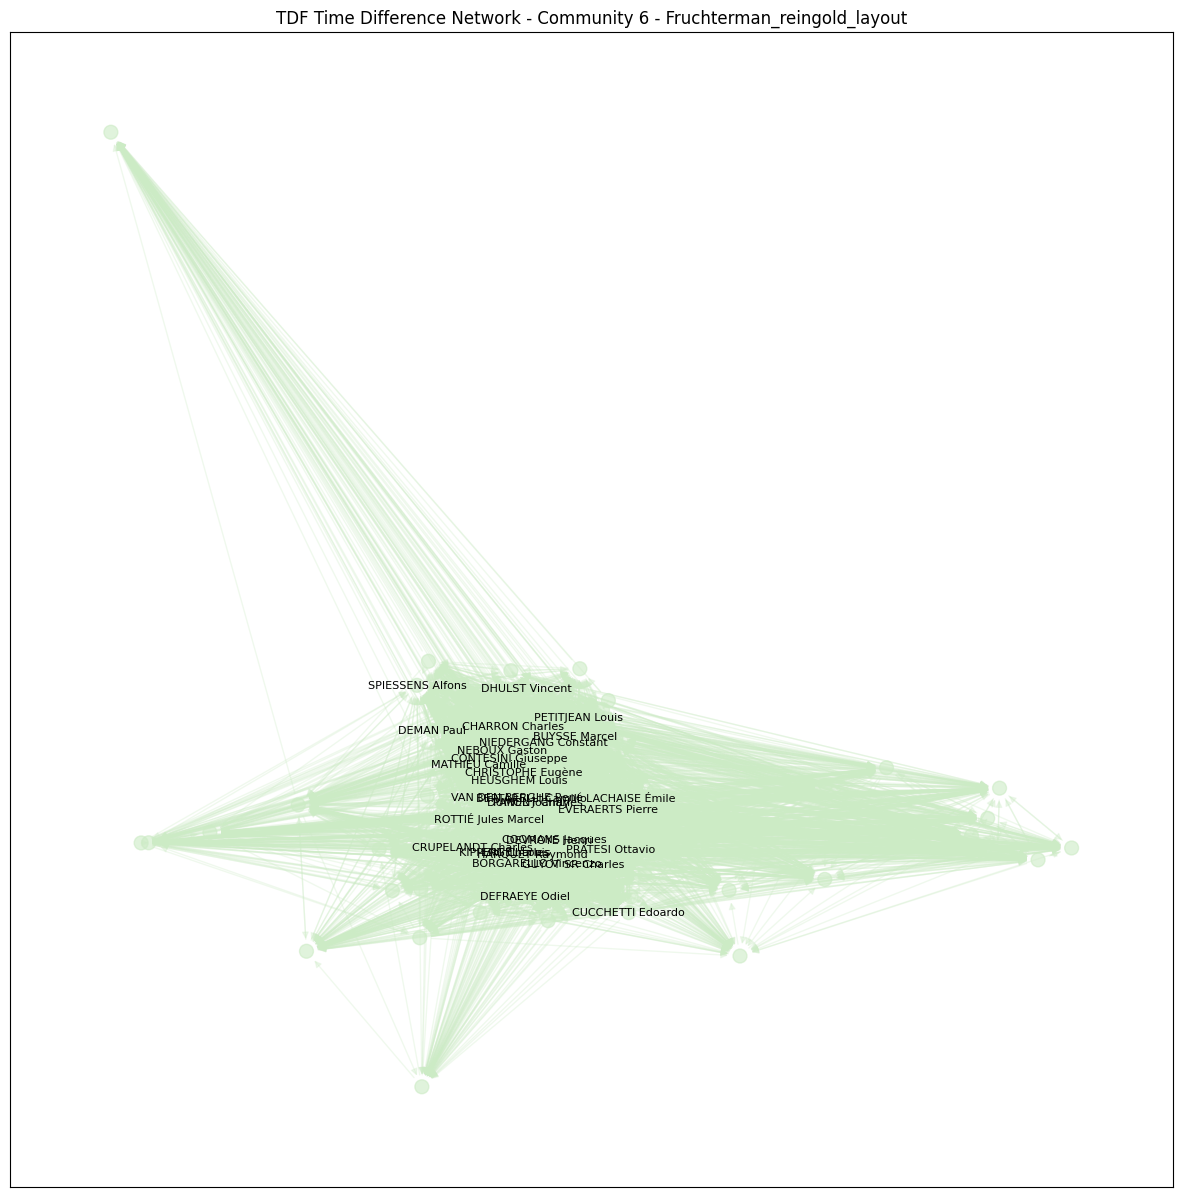

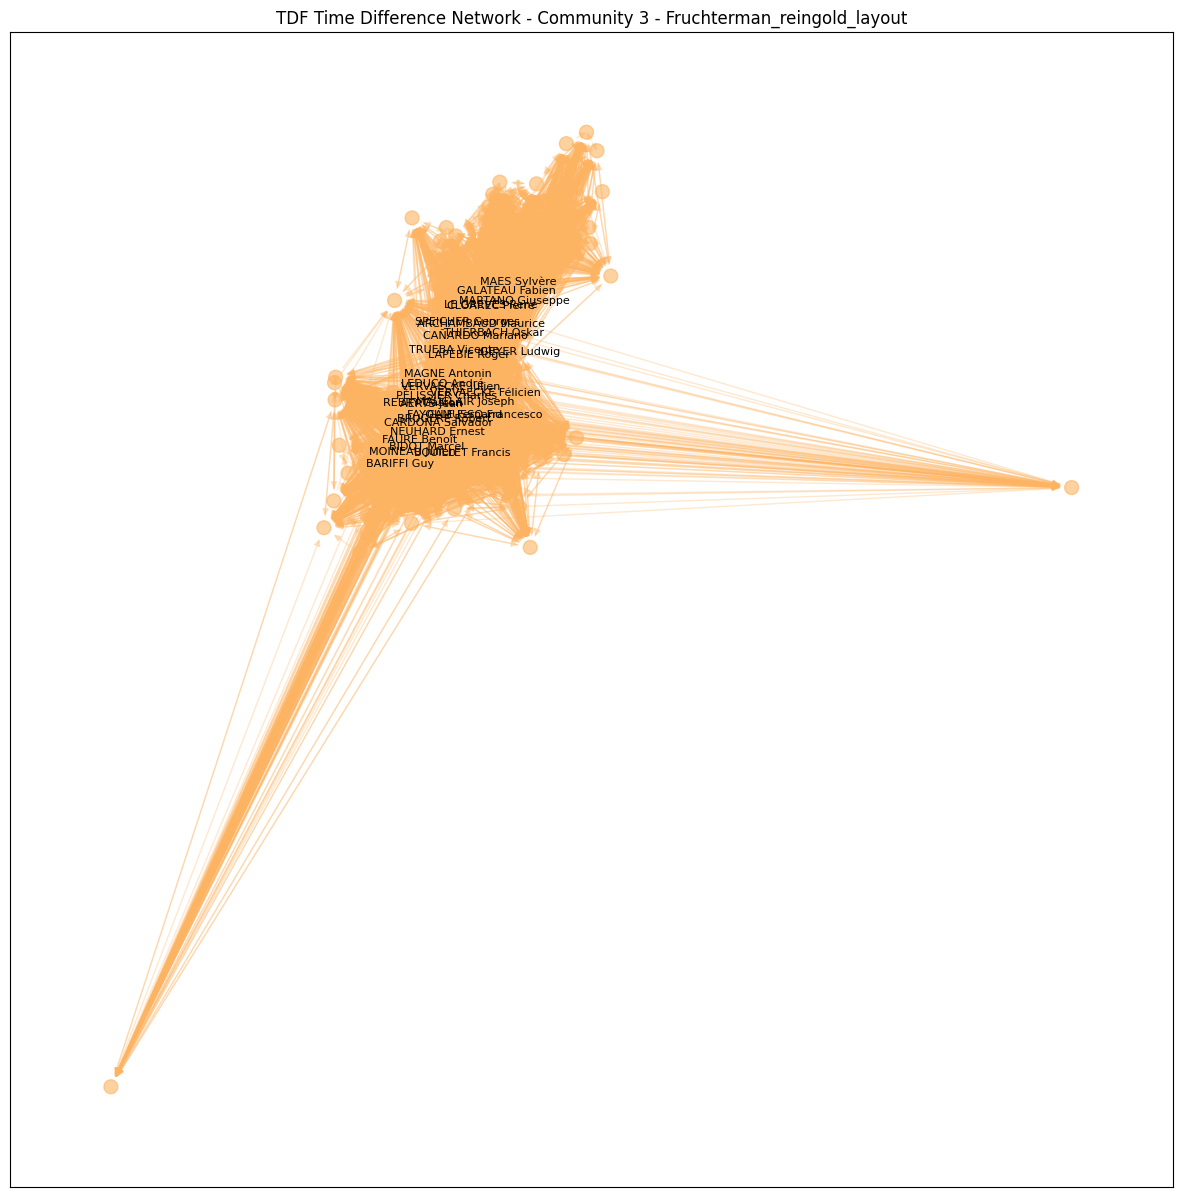

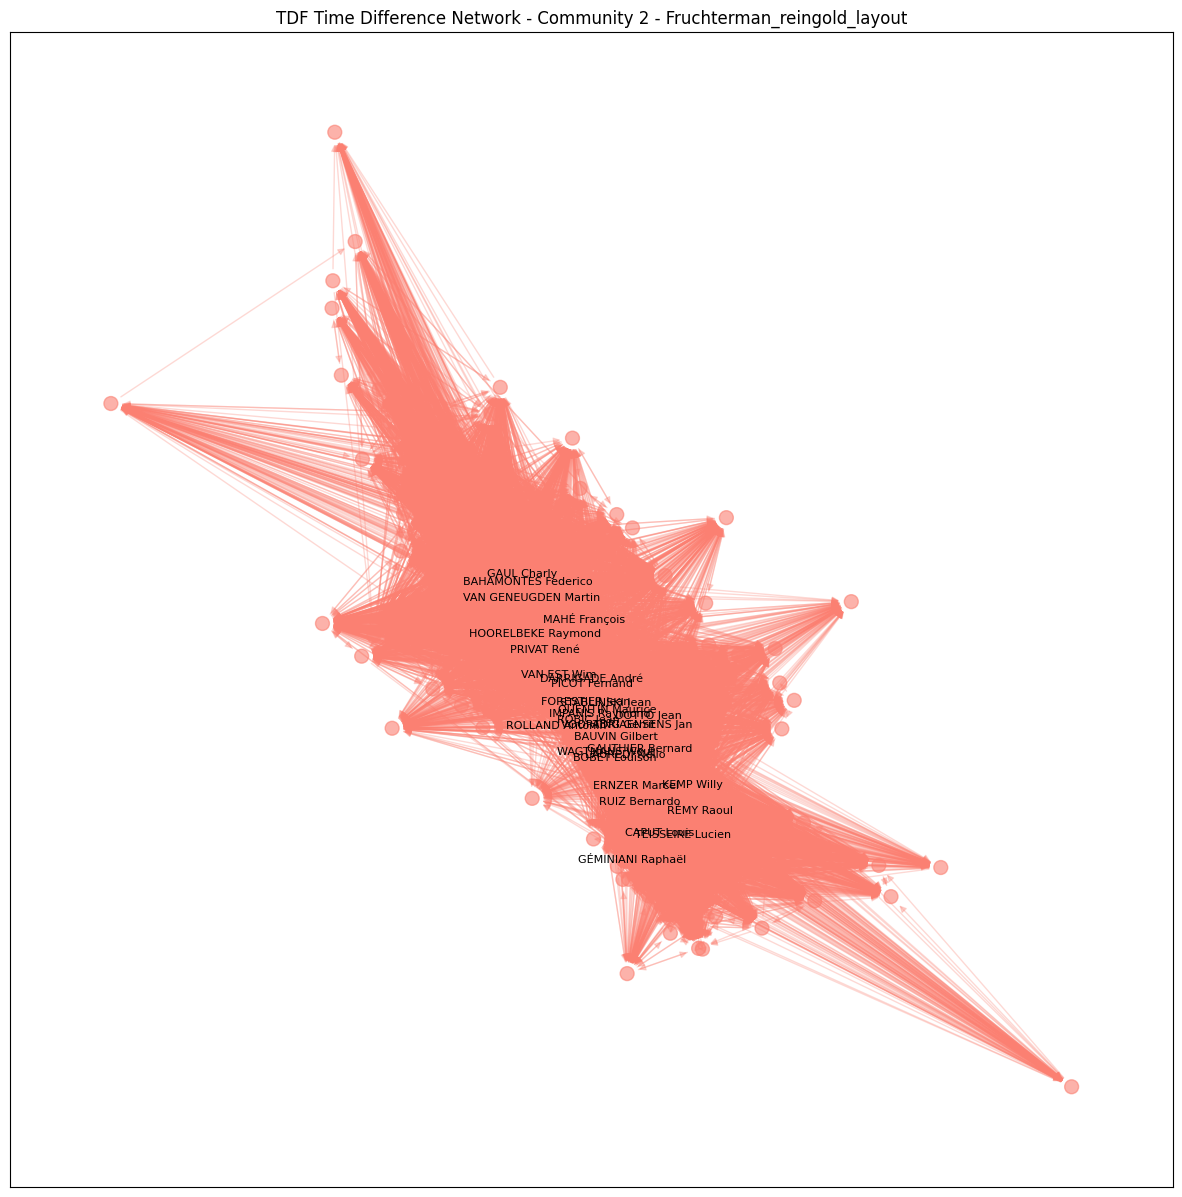

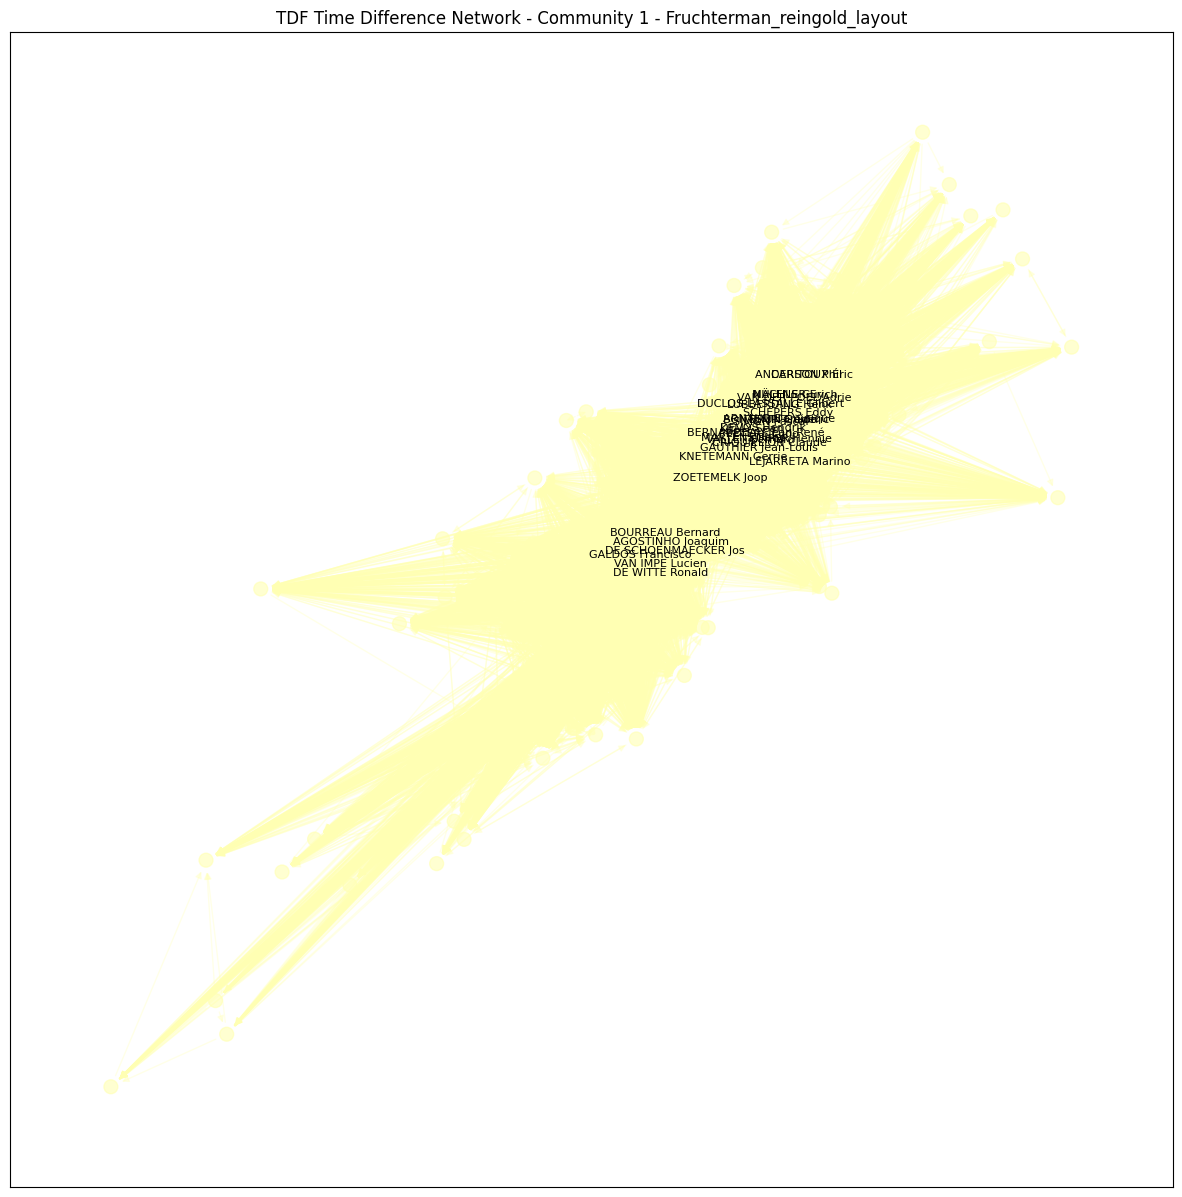

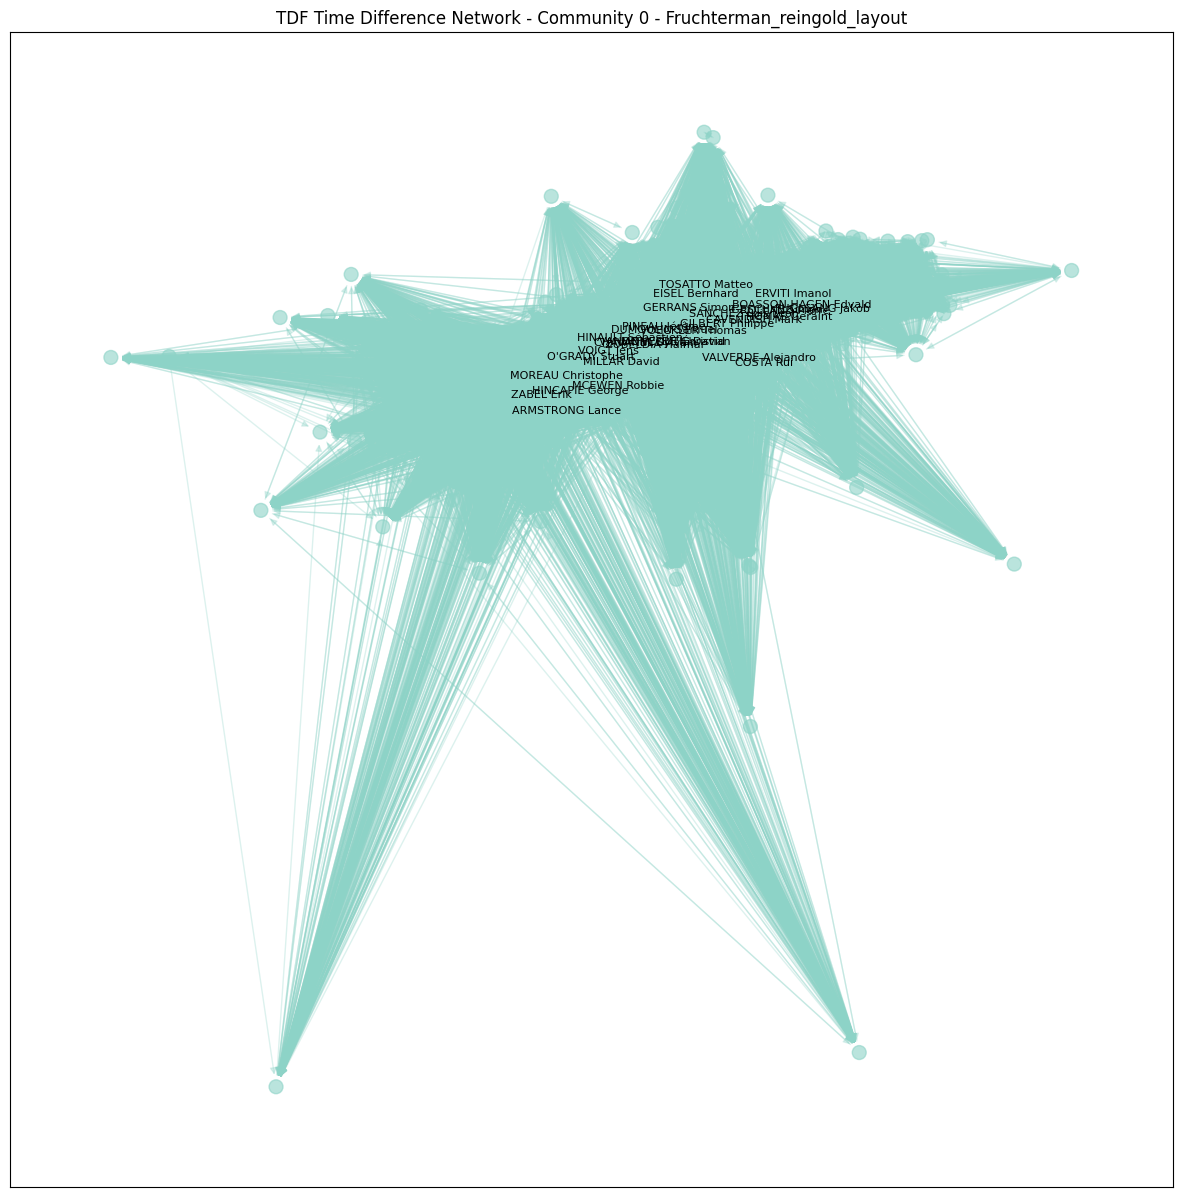

In [5]:
G_time_diff, names = read_pajek("TDF_time_diff", "../output_graphs")

visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='fruchterman_reingold_layout',
    resolution=1,
    plot_communities=True
)

C:\Users\tgrum\AppData\Local\Temp\ipykernel_17388\1920711012.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


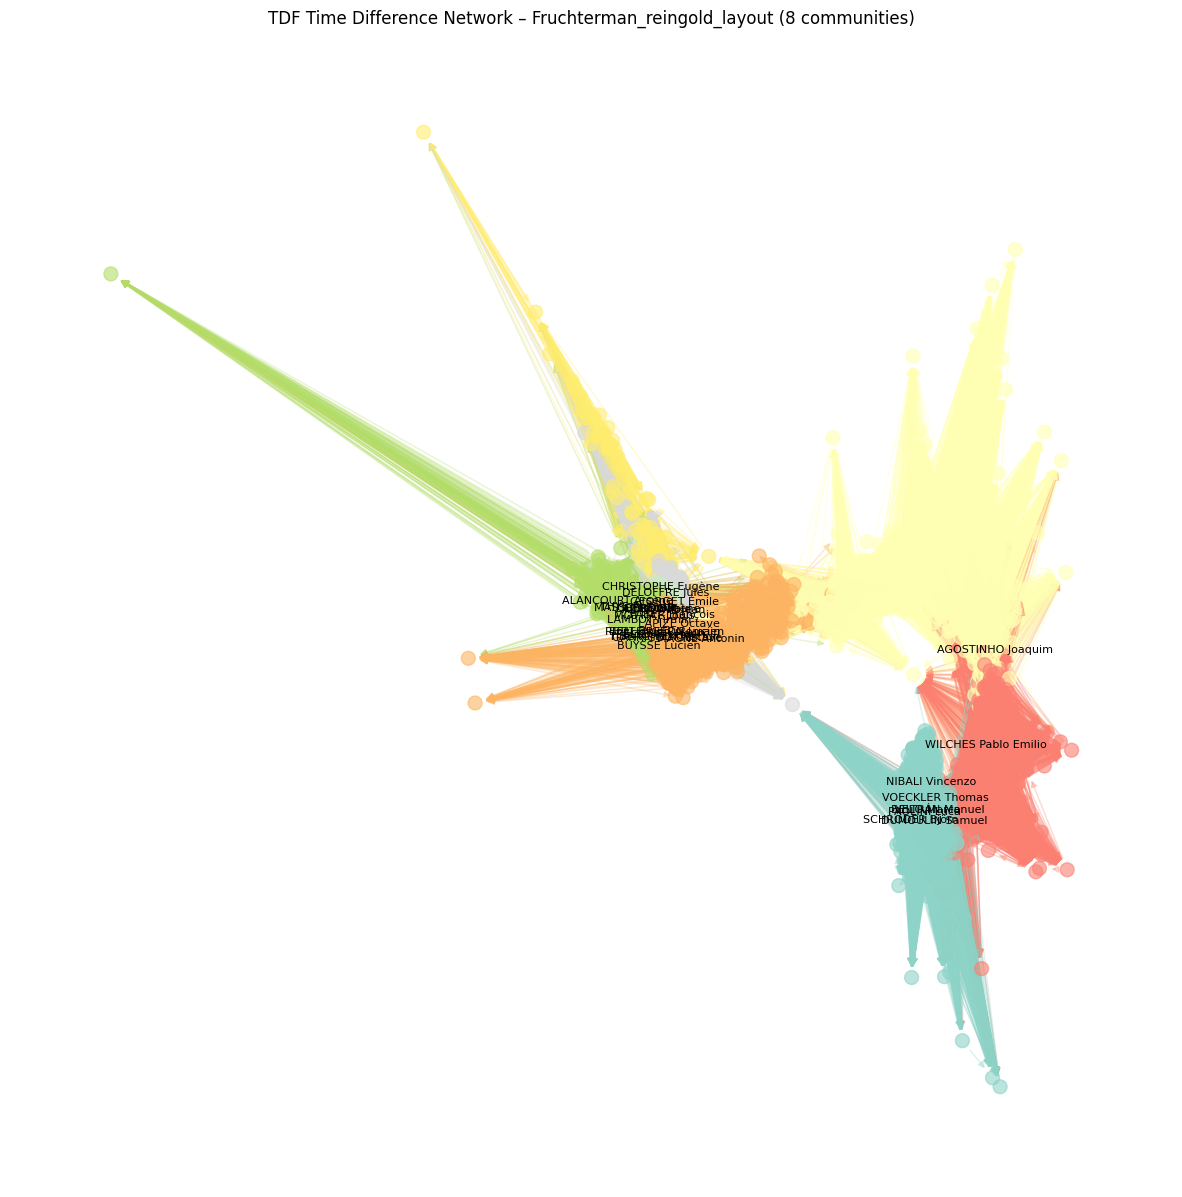

Created main network visualization with fruchterman_reingold_layout layout: tdf_time_diff_fruchterman_reingold_layout.png


In [6]:
visualize_network(
    G_time_diff,
    'TDF Time Difference Network',
    'tdf_time_diff',
    layout_name='fruchterman_reingold_layout',
    resolution=1,
    plot_communities=False
)

# TDF_normalized_time_diff.net

Successfully loaded network with 409 nodes and 102635 edges
Successfully loaded network with 409 nodes and 102635 edges


C:\Users\tgrum\AppData\Local\Temp\ipykernel_4508\4070147902.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


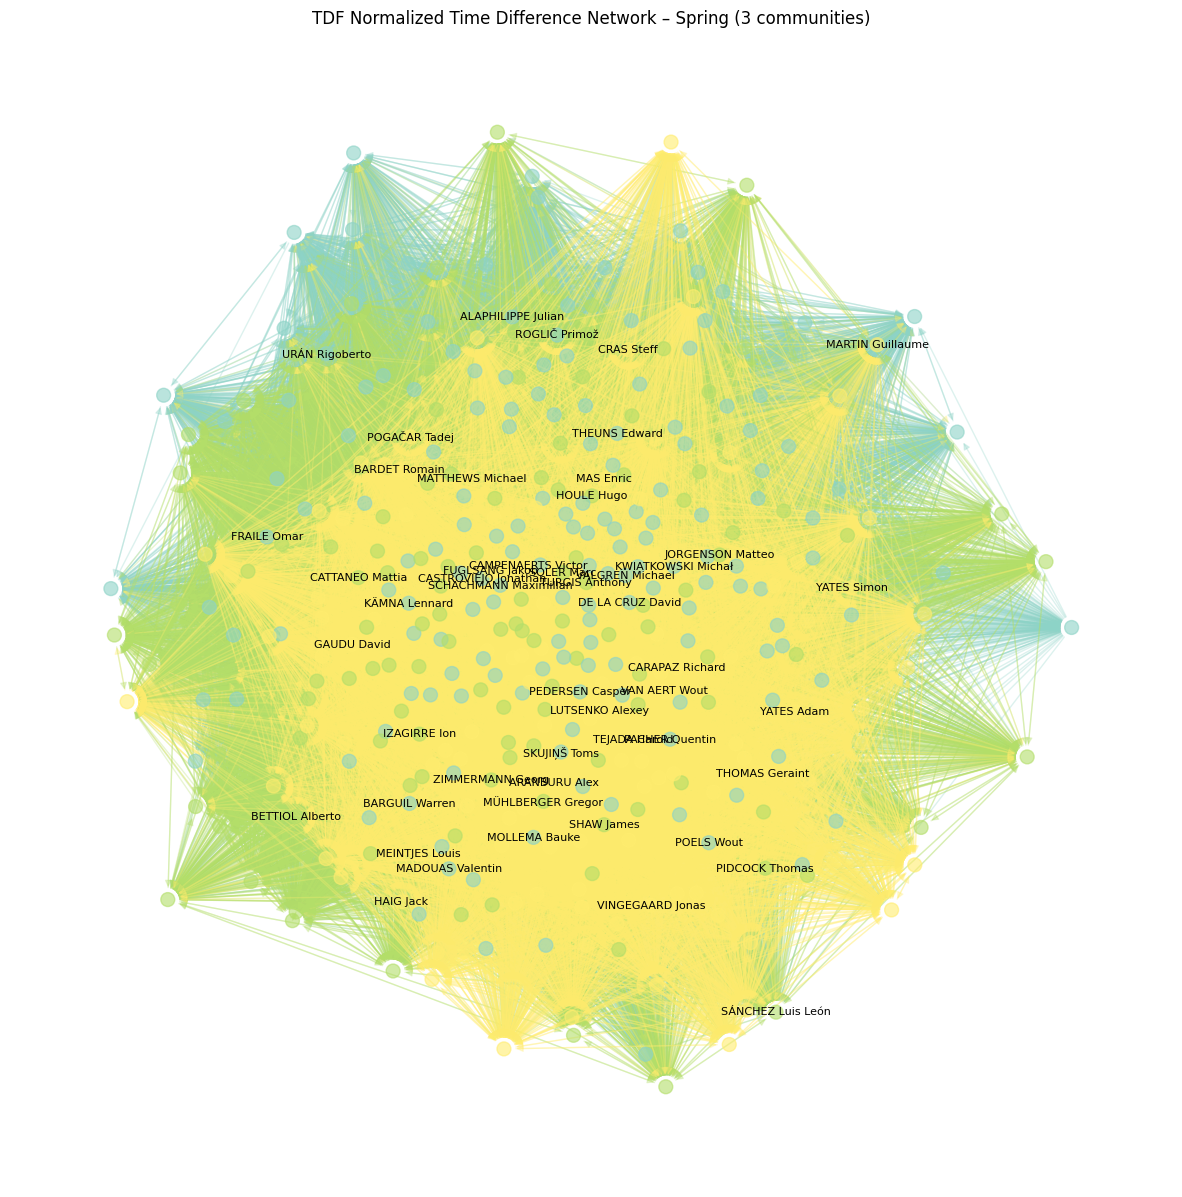

Created network visualization with spring layout: tdf_normalized_time_diff_test_spring.png


C:\Users\tgrum\AppData\Local\Temp\ipykernel_4508\4070147902.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set3', num_comms)


KeyboardInterrupt: 

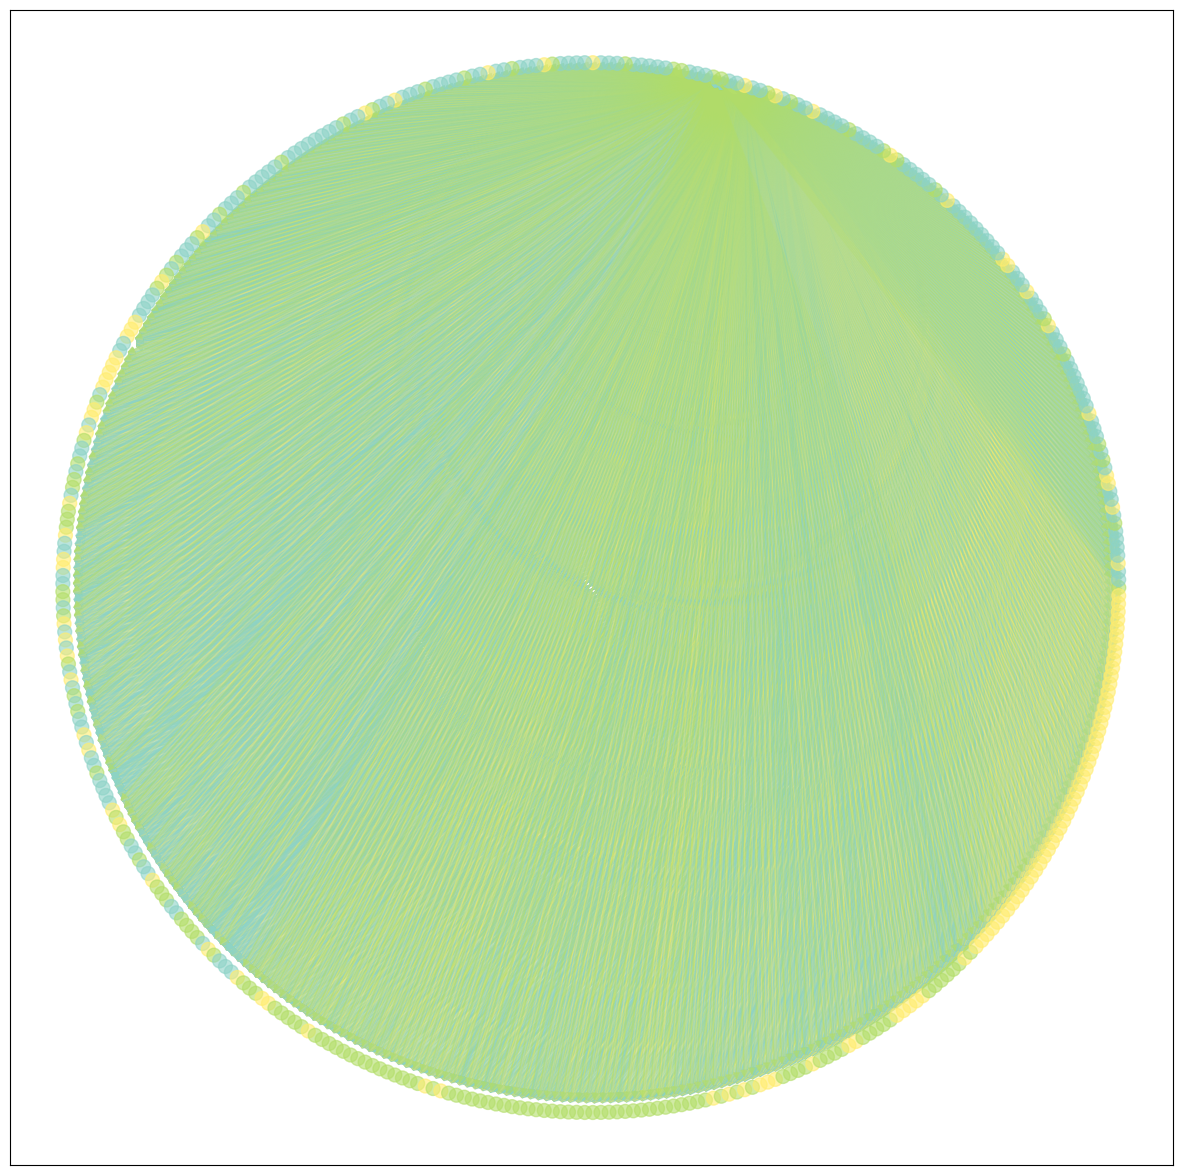

In [3]:



G_normalized_time_diff, names = read_pajek("TDF_normalized_time_diff", "../smallest_graphs")
print(f"Successfully loaded network with {G_normalized_time_diff.number_of_nodes()} nodes "
      f"and {G_normalized_time_diff.number_of_edges()} edges")


print(f"Successfully loaded network with {G_normalized_time_diff.number_of_nodes()} nodes and {G_normalized_time_diff.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff_test',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_normalized_time_diff,
    'TDF Normalized Time Difference Network',
    'tdf_normalized_time_diff',
    layout_name='kamada_kawai',
    resolution=1
)

# TDF_scaled_time_diff.net

In [3]:
# TODO: Haven't tried this yet
# Load scaled_time_diff network
G_scaled_time_diff, names = read_pajek("TDF_scaled_time_diff", "../smaller_graphs")
print(f"Successfully loaded network with {G_scaled_time_diff.number_of_nodes()} nodes and {G_scaled_time_diff.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_scaled_time_diff,
    'TDF Scaled Time Difference Network',
    'tdf_scaled_time_diff',
    layout_name='kamada_kawai',
    resolution=1
)

KeyboardInterrupt: 

# TDF_points.net

In [4]:
# TODO: Haven't tried this yet
# Load points network
G_points, names = read_pajek("TDF_points", "../smaller_graphs")
print(f"Successfully loaded network with {G_points.number_of_nodes()} nodes and {G_points.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_points,
    'TDF Points Network',
    'tdf_points',
    layout_name='kamada_kawai',
    resolution=1
)

KeyboardInterrupt: 

# TDF_pure_points.net


In [ ]:
# TODO: Haven't tried this yet
# Load pure_points network
G_pure_points, names = read_pajek("TDF_pure_points", "../smaller_graphs")
print(f"Successfully loaded network with {G_pure_points.number_of_nodes()} nodes and {G_pure_points.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_pure_points,
    'TDF Pure Points Network',
    'tdf_pure_points',
    layout_name='kamada_kawai',
    resolution=1
)

# TDF_no_weights.net

In [ ]:
# TODO: Haven't tried this yet
# Load no_weights network
G_no_weights, names = read_pajek("TDF_no_weights", "../smaller_graphs")
print(f"Successfully loaded network with {G_no_weights.number_of_nodes()} nodes and {G_no_weights.number_of_edges()} edges")

# Spring layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='spring',
    resolution=1
)

# Circular layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='circular',
    resolution=1
)

# Random layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='random',
    resolution=1
)

# Shell layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='shell',
    resolution=1
)

# Spiral layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='spiral',
    resolution=1
)

# Spectral layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='spectral',
    resolution=1
)

# Kamada-Kawai layout
visualize_network(
    G_no_weights,
    'TDF No Weights Network',
    'tdf_no_weights',
    layout_name='kamada_kawai',
    resolution=1
)